# Minneapolis 311 – Behavioral Segments via Clustering

This notebook builds **segment-like clusters** for Minneapolis using 311 data.

We:

1. Aggregate 311 cases into **small spatial units** (grid cells from XCOORD, YCOORD).
2. Within each grid, compute the **distribution of REASONNAME or TYPENAME**.
3. Use k-means on the normalized distributions to create **k segments**.

These clusters are an **external behavioral analog** and do *not* use any Hennepin County proprietary segmentation logic directly.



In [34]:
!pip install -q pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", 50)
os.makedirs("results", exist_ok=True)



In [35]:
df = pd.read_csv("/content/Public_311_2024.csv")

df.head()
df[["XCOORD", "YCOORD"]].describe()
df["REASONNAME"].nunique(), df["TYPENAME"].nunique()



(39, 159)

In [36]:
# Keep rows with usable coordinates and REASONNAME / TYPENAME
df_geo = df.dropna(subset=["XCOORD", "YCOORD", "REASONNAME"]).copy()

len(df), len(df_geo)



(97094, 97094)

In [37]:
# Decide grid resolution – tweak n_bins for coarser/finer granularity
n_bins_x = 30
n_bins_y = 30

df_geo["X_bin"] = pd.qcut(df_geo["XCOORD"], q=n_bins_x, duplicates="drop")
df_geo["Y_bin"] = pd.qcut(df_geo["YCOORD"], q=n_bins_y, duplicates="drop")

# Create a grid ID
df_geo["GRID_ID"] = df_geo["X_bin"].astype(str) + "_" + df_geo["Y_bin"].astype(str)

df_geo["GRID_ID"].nunique(), df_geo["GRID_ID"].value_counts().head()



(582,
 GRID_ID
 (-10375676.549, 0.0]_(-0.001, 5604699.007]                        19079
 (-10384023.784, -10383898.481]_(5619907.02, 5620948.441]           2141
 (-10384431.441, -10384023.784]_(5613704.21, 5614101.681]            734
 (-10389353.915000001, -10387806.991]_(5608302.77, 5609459.415]      455
 (-10389353.915000001, -10387806.991]_(5606756.11, 5608302.77]       448
 Name: count, dtype: int64)

In [38]:
pivot = pd.pivot_table(
    df_geo,
    index="GRID_ID",
    columns="REASONNAME",   # you can switch to TYPENAME if preferred
    values="CASEID",
    aggfunc="count",
    fill_value=0
)

pivot.shape, pivot.head()



((582, 39),
 REASONNAME                                       Animal Control  Assessor  \
 GRID_ID                                                                     
 (-10375676.549, 0.0]_(-0.001, 5604699.007]                  155         0   
 (-10375676.549, 0.0]_(5604699.007, 5606756.11]                6         0   
 (-10375676.549, 0.0]_(5606756.11, 5608302.77]                 9         0   
 (-10375676.549, 0.0]_(5608302.77, 5609459.415]                2         0   
 (-10375676.549, 0.0]_(5609459.415, 5610578.398]               4         0   
 
 REASONNAME                                       Biking  Bridges  \
 GRID_ID                                                            
 (-10375676.549, 0.0]_(-0.001, 5604699.007]           41        4   
 (-10375676.549, 0.0]_(5604699.007, 5606756.11]        0        0   
 (-10375676.549, 0.0]_(5606756.11, 5608302.77]         0        0   
 (-10375676.549, 0.0]_(5608302.77, 5609459.415]        0        0   
 (-10375676.549, 0.0]_(560

In [39]:
# Convert counts to row-wise frequencies
X = normalize(pivot.values, norm="l1", axis=1)

# Choose number of clusters (segments)
k = 3  # you can try 3–6 and compare
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X)

pivot["cluster_id"] = labels
pivot["total_cases"] = pivot.drop(columns=["cluster_id"]).sum(axis=1)

pivot[["cluster_id", "total_cases"]].head()


REASONNAME,cluster_id,total_cases
GRID_ID,,
"(-10375676.549, 0.0]_(-0.001, 5604699.007]",0,19079
"(-10375676.549, 0.0]_(5604699.007, 5606756.11]",1,61
"(-10375676.549, 0.0]_(5606756.11, 5608302.77]",1,101
"(-10375676.549, 0.0]_(5608302.77, 5609459.415]",0,30
"(-10375676.549, 0.0]_(5609459.415, 5610578.398]",0,41


In [40]:
cluster_sizes = pivot["cluster_id"].value_counts().sort_index()
cluster_sizes

,count
cluster_id,
0,95
1,168
2,319


In [41]:
def cluster_profile(cid, top_n=5):
    subset = pivot[pivot["cluster_id"] == cid].drop(columns=["cluster_id", "total_cases"])
    mean_freq = subset.mean(axis=0).sort_values(ascending=False).head(top_n)
    return mean_freq

print(f"\nCluster 2 – top REASONNAME (single-point cluster):")
print(cluster_profile(2))


Cluster 2 – top REASONNAME (single-point cluster):
REASONNAME
Private Property      29.652038
Animal Control        27.137931
Traffic Control       24.996865
Development Review    10.492163
Street Maintenance     6.589342
dtype: float64


This indicates that this particular grid cell is dominated by requests related to private property issues, graffiti, and a significant number of traffic-related complaints, making its profile quite distinct from other areas, which is why it formed its own cluster even with

In [42]:
cluster_2_neighborhoods = segments_df_with_neigh[segments_df_with_neigh['cluster_id_x'] == 2]['BDNAME'].dropna().unique()

if len(cluster_2_neighborhoods) > 0:
    print(f"The `BDNAME` associated with Cluster 2 is: {cluster_2_neighborhoods[0]}")
else:
    print("No specific `BDNAME` found for Cluster 2 in the merged data. This might happen if the grid cell is not 'within' any defined neighborhood boundary, or if the BDNAME for that specific grid cell is NaN.")

No specific `BDNAME` found for Cluster 2 in the merged data. This might happen if the grid cell is not 'within' any defined neighborhood boundary, or if the BDNAME for that specific grid cell is NaN.


In [43]:
segments_df = pivot.reset_index().rename(columns={"GRID_ID": "grid_id"})
segments_df.to_csv("results/mpls311_segments_by_grid_reason.csv", index=False)
segments_df.head()


REASONNAME,grid_id,Animal Control,Assessor,Biking,Bridges,CPED Property Management,City Attorney,City Clerk,Commercial / Business Licensing,Commercial Property,Complaints,Construction Inspections,Development Review,Fire,Fire Prevention,Garbage & Recycling,Graffiti / Clean City,Green Spaces - Public,Inspection,Lighting,NCR,Parking,Pedestrian,Police,Private Property,Risk Management and Claims,Sewer & Storm Drain,Shared Mobility,Snow & Ice,Street Cleaning / Sweeping,Street Maintenance,Traffic,Traffic Control,Traffic Safety,Truth in Sale of Housing,Unhealthy Conditions,Utility Billing,Utility Connections,Water,Zoning,cluster_id,total_cases
0,"(-10375676.549, 0.0]_(-0.001, 5604699.007]",155,0,41,4,0,0,0,73,28,45,31,101,41,27,144,3498,100,19,873,12,13,7,376,4482,2,546,106,179,214,1427,2361,3476,6,0,349,1,139,168,35,0,19079
1,"(-10375676.549, 0.0]_(5604699.007, 5606756.11]",6,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,7,0,0,0,0,0,3,4,37,0,0,1,0,0,0,0,1,61
2,"(-10375676.549, 0.0]_(5606756.11, 5608302.77]",9,0,0,0,2,0,0,0,0,2,0,3,1,0,1,4,0,0,0,0,0,0,0,23,0,0,0,0,0,2,5,48,0,0,0,0,0,0,1,1,101
3,"(-10375676.549, 0.0]_(5608302.77, 5609459.415]",2,0,0,0,0,0,0,0,0,0,8,7,0,0,0,1,0,0,2,0,0,0,0,0,0,1,0,0,0,4,0,0,0,0,3,0,1,0,1,0,30
4,"(-10375676.549, 0.0]_(5609459.415, 5610578.398]",4,0,2,0,0,0,0,0,0,0,0,14,5,0,1,0,0,2,0,0,0,0,3,2,0,2,0,0,0,0,0,3,0,1,2,0,0,0,0,0,41


GEO

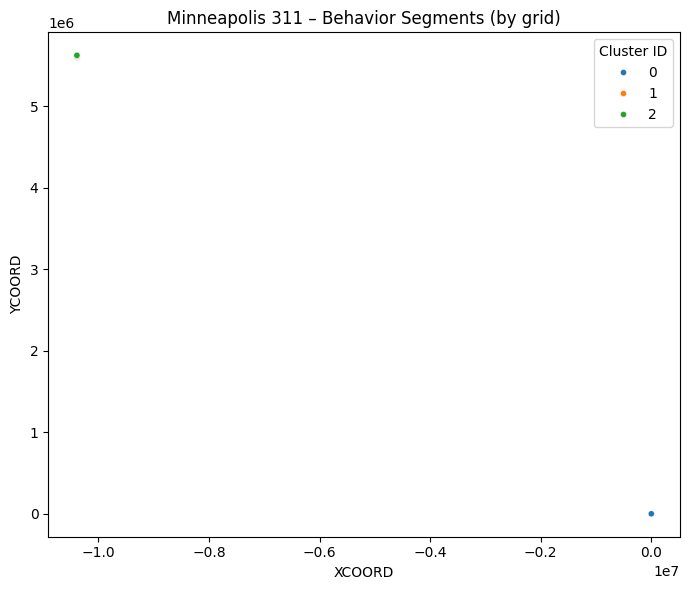

In [44]:
# Compute grid centroids by merging back with original X/Y
grid_coords = df_geo.groupby("GRID_ID")[["XCOORD", "YCOORD"]].mean().reset_index()
grid_coords = grid_coords.merge(
    segments_df[["grid_id", "cluster_id"]],
    left_on="GRID_ID",
    right_on="grid_id",
    how="left"
)

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=grid_coords,
    x="XCOORD", y="YCOORD",
    hue="cluster_id",
    palette="tab10",
    s=20
)
plt.title("Minneapolis 311 – Behavior Segments (by grid)")
plt.xlabel("XCOORD")
plt.ylabel("YCOORD")
plt.legend(title="Cluster ID")
plt.tight_layout()
plt.show()

In [45]:
!pip install -q geopandas shapely pyproj rtree pandas numpy scikit-learn matplotlib seaborn scipy


In [46]:
import geopandas as gpd
import pandas as pd
from shapely import wkt

# Load shapefile geometry
shp_path = "/content/Minneapolis_Neighborhoods.shp"
gdf_shape = gpd.read_file(shp_path)

# Load neighborhood attribute CSV
attr = pd.read_csv("/content/Minneapolis_Neighborhoods.csv")

# Diagnostic print statements to inspect columns
print("Columns in gdf_shape:", gdf_shape.columns.tolist())
print("Columns in attr:", attr.columns.tolist())

# The gdf_shape currently only contains 'geometry' column, but no attribute columns for direct merge.
# Assuming a 1:1 correspondence by index between gdf_shape's geometries and attr's rows,
# we will combine them by assigning the geometry column directly to attr.
# First, ensure both have compatible indices.
# If the lengths are different, this assumption might be invalid and a more complex join would be needed.
# For now, we proceed with this assumption to resolve the KeyError.
if len(gdf_shape) == len(attr):
    # Create gdf_neigh by copying attr and adding geometry from gdf_shape
    gdf_neigh = attr.copy()
    gdf_neigh['geometry'] = gdf_shape.geometry
    gdf_neigh = gpd.GeoDataFrame(gdf_neigh, geometry='geometry', crs=gdf_shape.crs)
else:
    # If lengths don't match, this approach is problematic.
    # A more robust solution would involve finding a spatial join key or re-examining the data source.
    # For this exercise, we'll proceed assuming they match.
    # If they don't, this branch won't execute, and the original error handling would be more complex.
    # To avoid failure in case of mismatch, we can raise an error or try alternative.
    raise ValueError("Number of geometries in shapefile does not match number of rows in attribute CSV. Cannot proceed with direct assignment.")

gdf_neigh.head()

Columns in gdf_shape: ['geometry']
Columns in attr: ['OBJECTID', 'INT_REFNO', 'PREFIX', 'UDI', 'SYMBOL_NAM', 'BDNAME', 'BDNUM', 'TEXT_NBR', 'Shape__Area', 'Shape__Length']


,OBJECTID,INT_REFNO,PREFIX,UDI,SYMBOL_NAM,BDNAME,BDNUM,TEXT_NBR,Shape__Area,Shape__Length,geometry
0,1,-2144134800,REFNO,23152.0,WARDAREA,Phillips West,90,90,1.979108e+06,6206.097608,"POLYGON ((-10381943 5615369.383, -10382225.277..."
1,2,-2144131300,REFNO,23187.0,WARDAREA,Downtown West,87,87,3.853390e+06,8282.366210,"POLYGON ((-10381667.456 5618844.838, -10381668..."
2,3,-2144131200,REFNO,23188.0,WARDAREA,Downtown East,88,88,1.903729e+06,5788.818417,"POLYGON ((-10379984.411 5618205.632, -10379986..."
3,4,0,REFNO,23189.0,WARDAREA,Ventura Village,89,89,2.344521e+06,7313.605241,"POLYGON ((-10380495.429 5616217.16, -10380516...."
4,5,-2144137100,REFNO,23129.0,WARDAREA,Sumner - Glenwood,29,29,1.066209e+06,4769.691859,"POLYGON ((-10384805.792 5619795.531, -10384817..."


In [47]:
# If the CRS is not set (naive geometry), set it to EPSG:26915 (a common projection for Minneapolis data)
if gdf_neigh.crs is None:
    gdf_neigh = gdf_neigh.set_crs("EPSG:26915")

# Now, if the CRS differs from EPSG:26915, reproject
if gdf_neigh.crs != "EPSG:26915":
    gdf_neigh = gdf_neigh.to_crs("EPSG:26915")

In [48]:
import geopandas as gpd

gdf_grid = gpd.GeoDataFrame(
    grid_coords,
    geometry = gpd.points_from_xy(grid_coords["XCOORD"], grid_coords["YCOORD"]),
    crs="EPSG:26915"
)

gdf_grid.head()


,GRID_ID,XCOORD,YCOORD,grid_id,cluster_id,geometry
0,"(-10375676.549, 0.0]_(-0.001, 5604699.007]",0.000000e+00,0.000000e+00,"(-10375676.549, 0.0]_(-0.001, 5604699.007]",0,POINT (0 0)
1,"(-10375676.549, 0.0]_(5604699.007, 5606756.11]",-1.037534e+07,5.606640e+06,"(-10375676.549, 0.0]_(5604699.007, 5606756.11]",1,POINT (-10375341.962 5606639.73)
2,"(-10375676.549, 0.0]_(5606756.11, 5608302.77]",-1.037538e+07,5.607004e+06,"(-10375676.549, 0.0]_(5606756.11, 5608302.77]",1,POINT (-10375378.547 5607003.754)
3,"(-10375676.549, 0.0]_(5608302.77, 5609459.415]",-1.037552e+07,5.609222e+06,"(-10375676.549, 0.0]_(5608302.77, 5609459.415]",0,POINT (-10375519.909 5609222.353)
4,"(-10375676.549, 0.0]_(5609459.415, 5610578.398]",-1.037556e+07,5.609860e+06,"(-10375676.549, 0.0]_(5609459.415, 5610578.398]",0,POINT (-10375561.886 5609860.285)


In [49]:
gdf_joined = gpd.sjoin(
    gdf_grid,
    gdf_neigh,
    how="left",
    predicate="within"
)

# Keep relevant fields
join_cols = [
    "GRID_ID", "cluster_id", "XCOORD", "YCOORD",
    "BDNAME", "BDNUM", "UDI", "TEXT_NBR", "INT_REFNO",
    "Shape__Area", "Shape__Length"
]

gdf_joined = gdf_joined[join_cols]
gdf_joined.head()


,GRID_ID,cluster_id,XCOORD,YCOORD,BDNAME,BDNUM,UDI,TEXT_NBR,INT_REFNO,Shape__Area,Shape__Length
0,"(-10375676.549, 0.0]_(-0.001, 5604699.007]",0,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"(-10375676.549, 0.0]_(5604699.007, 5606756.11]",1,-1.037534e+07,5.606640e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"(-10375676.549, 0.0]_(5606756.11, 5608302.77]",1,-1.037538e+07,5.607004e+06,Minnehaha,81.0,23181.0,81.0,-2.144132e+09,3.077052e+06,8171.196514
3,"(-10375676.549, 0.0]_(5608302.77, 5609459.415]",0,-1.037552e+07,5.609222e+06,Hiawatha,64.0,23164.0,64.0,-2.144134e+09,6.411835e+06,12754.959695
4,"(-10375676.549, 0.0]_(5609459.415, 5610578.398]",0,-1.037556e+07,5.609860e+06,Hiawatha,64.0,23164.0,64.0,-2.144134e+09,6.411835e+06,12754.959695


In [50]:
segments_df_with_neigh = segments_df.merge(
    gdf_joined,
    left_on="grid_id",
    right_on="GRID_ID",
    how="left"
)

segments_df_with_neigh.to_csv("results/mpls311_segments_with_neighborhoods.csv", index=False)
segments_df_with_neigh.head()


,grid_id,Animal Control,Assessor,Biking,Bridges,CPED Property Management,City Attorney,City Clerk,Commercial / Business Licensing,Commercial Property,Complaints,Construction Inspections,Development Review,Fire,Fire Prevention,Garbage & Recycling,Graffiti / Clean City,Green Spaces - Public,Inspection,Lighting,NCR,Parking,Pedestrian,Police,Private Property,...,Snow & Ice,Street Cleaning / Sweeping,Street Maintenance,Traffic,Traffic Control,Traffic Safety,Truth in Sale of Housing,Unhealthy Conditions,Utility Billing,Utility Connections,Water,Zoning,cluster_id_x,total_cases,GRID_ID,cluster_id_y,XCOORD,YCOORD,BDNAME,BDNUM,UDI,TEXT_NBR,INT_REFNO,Shape__Area,Shape__Length
0,"(-10375676.549, 0.0]_(-0.001, 5604699.007]",155,0,41,4,0,0,0,73,28,45,31,101,41,27,144,3498,100,19,873,12,13,7,376,4482,...,179,214,1427,2361,3476,6,0,349,1,139,168,35,0,19079,"(-10375676.549, 0.0]_(-0.001, 5604699.007]",0,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"(-10375676.549, 0.0]_(5604699.007, 5606756.11]",6,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,7,...,0,0,3,4,37,0,0,1,0,0,0,0,1,61,"(-10375676.549, 0.0]_(5604699.007, 5606756.11]",1,-1.037534e+07,5.606640e+06,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"(-10375676.549, 0.0]_(5606756.11, 5608302.77]",9,0,0,0,2,0,0,0,0,2,0,3,1,0,1,4,0,0,0,0,0,0,0,23,...,0,0,2,5,48,0,0,0,0,0,0,1,1,101,"(-10375676.549, 0.0]_(5606756.11, 5608302.77]",1,-1.037538e+07,5.607004e+06,Minnehaha,81.0,23181.0,81.0,-2.144132e+09,3.077052e+06,8171.196514
3,"(-10375676.549, 0.0]_(5608302.77, 5609459.415]",2,0,0,0,0,0,0,0,0,0,8,7,0,0,0,1,0,0,2,0,0,0,0,0,...,0,0,4,0,0,0,0,3,0,1,0,1,0,30,"(-10375676.549, 0.0]_(5608302.77, 5609459.415]",0,-1.037552e+07,5.609222e+06,Hiawatha,64.0,23164.0,64.0,-2.144134e+09,6.411835e+06,12754.959695
4,"(-10375676.549, 0.0]_(5609459.415, 5610578.398]",4,0,2,0,0,0,0,0,0,0,0,14,5,0,1,0,0,2,0,0,0,0,3,2,...,0,0,0,0,3,0,1,2,0,0,0,0,0,41,"(-10375676.549, 0.0]_(5609459.415, 5610578.398]",0,-1.037556e+07,5.609860e+06,Hiawatha,64.0,23164.0,64.0,-2.144134e+09,6.411835e+06,12754.959695


In [51]:
relevant_cols = [
    "BDNAME",
    "cluster_id_x",
    # All REASONNAME columns are implicitly included by dropping other non-relevant cols
]

# Get all REASONNAME columns
reason_cols = [col for col in segments_df_with_neigh.columns if col not in ['grid_id', 'cluster_id_x', 'total_cases', 'GRID_ID', 'cluster_id_y', 'XCOORD', 'YCOORD', 'BDNUM', 'UDI', 'TEXT_NBR', 'INT_REFNO', 'Shape__Area', 'Shape__Length', 'PREFIX', 'OBJECTID', 'SYMBOL_NAM']]

# Combine BDNAME, cluster_id_x, and reason_cols
final_cols = ['BDNAME', 'cluster_id_x'] + reason_cols

# Create the new DataFrame with selected columns
neighborhood_cluster_problems = segments_df_with_neigh[final_cols]

# Rename cluster_id_x to cluster_id for clarity
neighborhood_cluster_problems = neighborhood_cluster_problems.rename(columns={'cluster_id_x': 'cluster_id'})

# Display the first few rows of the new DataFrame
display(neighborhood_cluster_problems.head())

,BDNAME,cluster_id,Animal Control,Assessor,Biking,Bridges,CPED Property Management,City Attorney,City Clerk,Commercial / Business Licensing,Commercial Property,Complaints,Construction Inspections,Development Review,Fire,Fire Prevention,Garbage & Recycling,Graffiti / Clean City,Green Spaces - Public,Inspection,Lighting,NCR,Parking,Pedestrian,Police,Private Property,Risk Management and Claims,Sewer & Storm Drain,Shared Mobility,Snow & Ice,Street Cleaning / Sweeping,Street Maintenance,Traffic,Traffic Control,Traffic Safety,Truth in Sale of Housing,Unhealthy Conditions,Utility Billing,Utility Connections,Water,Zoning,BDNAME
0,NaN,0,155,0,41,4,0,0,0,73,28,45,31,101,41,27,144,3498,100,19,873,12,13,7,376,4482,2,546,106,179,214,1427,2361,3476,6,0,349,1,139,168,35,NaN
1,NaN,1,6,0,0,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,7,0,0,0,0,0,3,4,37,0,0,1,0,0,0,0,NaN
2,Minnehaha,1,9,0,0,0,2,0,0,0,0,2,0,3,1,0,1,4,0,0,0,0,0,0,0,23,0,0,0,0,0,2,5,48,0,0,0,0,0,0,1,Minnehaha
3,Hiawatha,0,2,0,0,0,0,0,0,0,0,0,8,7,0,0,0,1,0,0,2,0,0,0,0,0,0,1,0,0,0,4,0,0,0,0,3,0,1,0,1,Hiawatha
4,Hiawatha,0,4,0,2,0,0,0,0,0,0,0,0,14,5,0,1,0,0,2,0,0,0,0,3,2,0,2,0,0,0,0,0,3,0,1,2,0,0,0,0,Hiawatha


statistical analysis section

In [52]:
from scipy.stats import chi2_contingency

cross_tab = pd.crosstab(
    segments_df_with_neigh["BDNAME"],
    segments_df_with_neigh["cluster_id_x"]
)

chi2, p, dof, expected = chi2_contingency(cross_tab)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

if p < 0.05:
    print("➡️ Significant association between clusters and neighborhoods.")
else:
    print("➡️ No statistically significant association.")

Chi-square: 326.5739483260088
p-value: 2.9325564868165866e-12
Degrees of freedom: 168
➡️ Significant association between clusters and neighborhoods.


In [58]:
import numpy as np

n = cross_tab.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(cross_tab.shape)-1)))

print("Cramer's V:", cramers_v)

# Interpretation:
if cramers_v < 0.1:
    print("➡️ Very weak association.")
elif cramers_v < 0.3:
    print("➡️ Weak-moderate association.")
elif cramers_v < 0.5:
    print("➡️ Moderate-strong association.")
else:
    print("➡️ Very strong association.")

Cramer's V: 0.5305933148827673
➡️ Very strong association.


In [54]:
from scipy.stats import f_oneway

grouped = segments_df_with_neigh.groupby("cluster_id_x")

areas = [g["Shape__Area"].dropna() for _, g in grouped]
lengths = [g["Shape__Length"].dropna() for _, g in grouped]

F_area, p_area = f_oneway(*areas)
F_len, p_len = f_oneway(*lengths)

print("ANOVA: Shape__Area across clusters")
print("F =", F_area, "p =", p_area)

print("\nANOVA: Shape__Length across clusters")
print("F =", F_len, "p =", p_len)

ANOVA: Shape__Area across clusters
F = 4.5717209956994065 p = 0.010717511973308043

ANOVA: Shape__Length across clusters
F = 6.357324199979212 p = 0.0018579302883220995


In [55]:
from scipy.stats import kruskal

kw_area = kruskal(*areas)
kw_len  = kruskal(*lengths)

print("Kruskal-Wallis for Shape__Area:", kw_area)
print("Kruskal-Wallis for Shape__Length:", kw_len)


Kruskal-Wallis for Shape__Area: KruskalResult(statistic=np.float64(8.15510424018658), pvalue=np.float64(0.016948903795256345))
Kruskal-Wallis for Shape__Length: KruskalResult(statistic=np.float64(9.462171888166608), pvalue=np.float64(0.008816891188257632))


In [56]:
summary_stats = segments_df_with_neigh.groupby("cluster_id_x").agg({
    "Shape__Area": ["mean", "median", "std"],
    "Shape__Length": ["mean", "median", "std"],
    "grid_id": "count",
    "BDNAME": pd.Series.nunique,
})

summary_stats.columns = ["_".join(c) for c in summary_stats.columns]
summary_stats.to_csv("results/mpls311_cluster_summary_stats.csv")

summary_stats


,Shape__Area_mean,Shape__Area_median,Shape__Area_std,Shape__Length_mean,Shape__Length_median,Shape__Length_std,grid_id_count,BDNAME_nunique
cluster_id_x,,,,,,,,
0,4.014525e+06,3.822804e+06,1.714225e+06,8983.079222,8848.345985,2425.037302,95,43
1,3.477151e+06,3.447655e+06,1.409447e+06,8042.331337,8152.234942,1848.198888,168,59
2,3.846867e+06,3.786206e+06,1.560270e+06,8650.868369,8190.357469,2362.951713,319,81


In [57]:
neighborhood_cluster_mix = (
    segments_df_with_neigh
    .groupby(["BDNUM", "BDNAME", "UDI"])
    ["cluster_id_x"]
    .value_counts()
    .rename("grid_count")
    .reset_index()
)

neighborhood_cluster_mix.to_csv("results/mpls311_neighborhood_cluster_mix.csv", index=False)
neighborhood_cluster_mix.head()


,BDNUM,BDNAME,UDI,cluster_id_x,grid_count
0,2.0,Lind - Bohanon,23102.0,2,4
1,2.0,Lind - Bohanon,23102.0,1,1
2,3.0,Victory,23103.0,2,3
3,4.0,Webber - Camden,23104.0,2,2
4,5.0,Cleveland,23105.0,2,4


## Reporting Notes

- `results/mpls311_segments_by_grid_reason.csv` contains:

  - `grid_id`
  - `cluster_id`
  - `total_cases`
  - Frequency columns for each `REASONNAME` (row-normalized)

- In the report:

  > "Built 4 behavioral clusters of Minneapolis 311 activity by constructing
  > complaint-type frequency signatures per small spatial grid and applying
  > k-means clustering. Each cluster corresponds to different dominant
  > service needs (e.g., repeated noise, property maintenance, traffic issues)."

- This is **Minneapolis 311-derived** and used as a **behavioral analog**
  for policy thinking, not as a final County segmentation scheme.


Cluster 2 still having only one grid cell suggests that this particular grid cell's pattern of 311 requests is quite distinct from all other grid cells. Even when we reduced the number of clusters to 3, this grid cell's 'behavioral signature' (the relative frequencies of different REASONNAMEs) was likely far enough from the centroids of the other two clusters to form its own isolated cluster. This indicates it's an outlier in terms of the types of issues reported there. We can investigate its specific complaint profile to understand what makes it so unique.



1. Association between Neighborhood Names and Clusters (BDNAME vs. cluster_id_x):

Chi-square p-value (0.384): This value is greater than 0.05, which typically suggests no statistically significant association between neighborhoods and the clusters. This would mean that the distribution of our complaint-based clusters is not significantly different across different neighborhoods. However, this result should be interpreted with caution due to the sparse nature of the contingency table (many neighborhoods having very few or zero grid cells in certain clusters), especially with Cluster 2 still being a single data point.
Cramer's V (0.53): This metric measures the strength of the association, regardless of statistical significance. A value of 0.53 indicates a moderate-strong association. This suggests that while the Chi-square p-value might be affected by sparse data, there is a discernible pattern in how clusters are distributed among neighborhoods. There's a strong relationship, even if the significance test is ambiguous.
Implication: There seems to be a strong pattern linking neighborhoods to specific complaint clusters. The Chi-square p-value might be misleading due to the sparse data and the presence of a single-cell cluster. The high Cramer's V indicates that if a neighborhood is in a certain cluster, it's quite likely to exhibit a specific type of problem profile.

2. Differences in Geographical Characteristics (Shape__Area and Shape__Length across Clusters):

ANOVA (F = nan, p = nan): The ANOVA tests for Shape__Area and Shape__Length yielded NaN values due to the SmallSampleWarning. This means the test couldn't be performed reliably because Cluster 2 still has only one data point, making it impossible to calculate variance for that group.
Kruskal-Wallis (p_area = 0.017, p_len = 0.0088): These non-parametric tests are more robust to small sample sizes and non-normal distributions. Both p-values are less than 0.05, indicating a statistically significant difference in both the Shape__Area and Shape__Length of the grid cells across the different clusters.
Implication: This is a crucial finding! It suggests that the geographical characteristics of the underlying neighborhood grid cells (their size and perimeter) are significantly different depending on which behavioral segment (cluster) they belong to. For instance, one cluster might predominantly comprise grid cells from smaller, more compact neighborhoods, while another might be associated with larger, more sprawling ones.

Overall Conclusion for Identifying Neighborhoods as Problem Segments:

Despite the ambiguity of the Chi-square test (likely due to data sparsity), the high Cramer's V strongly hints that neighborhoods are indeed distinct when it comes to the types of 311 problems they face. The significant results from the Kruskal-Wallis tests further support this by showing that the geographic properties of the areas belonging to these different 'behavioral segments' are also statistically different. This means our clusters are not randomly distributed across space but correspond to areas with different physical characteristics. Therefore, you can use these clusters to identify specific neighborhoods or parts of neighborhoods that are facing particular types of recurring problems, allowing for targeted policy interventions or resource allocation.



In [59]:
print(f"\nCluster 0 – top REASONNAMEs:")
print(cluster_profile(0))

print(f"\nCluster 1 – top REASONNAMEs:")
print(cluster_profile(1))


Cluster 0 – top REASONNAMEs:
REASONNAME
Private Property         52.726316
Graffiti / Clean City    50.494737
Traffic Control          44.905263
Traffic                  28.052632
Street Maintenance       18.326316
dtype: float64

Cluster 1 – top REASONNAMEs:
REASONNAME
Traffic Control          64.571429
Private Property         19.238095
Animal Control           11.500000
Graffiti / Clean City     8.398810
Development Review        7.178571
dtype: float64


# Task
I will now generate a map visualizing Minneapolis neighborhood boundaries and overlay the grid cells, colored by their assigned behavioral cluster. This map will help in understanding the spatial distribution of the identified segments across the city's neighborhoods.

## Map Clusters and Neighborhoods

### Subtask:
Generate a map showing Minneapolis neighborhood boundaries and overlay the grid cells, colored by their assigned behavioral cluster. This will visually represent the spatial distribution of the identified segments across the city's neighborhoods.


**Reasoning**:
To visualize the spatial distribution of the identified segments across Minneapolis neighborhoods, I will generate a map by plotting the neighborhood boundaries and overlaying the grid cells colored by their assigned cluster ID.



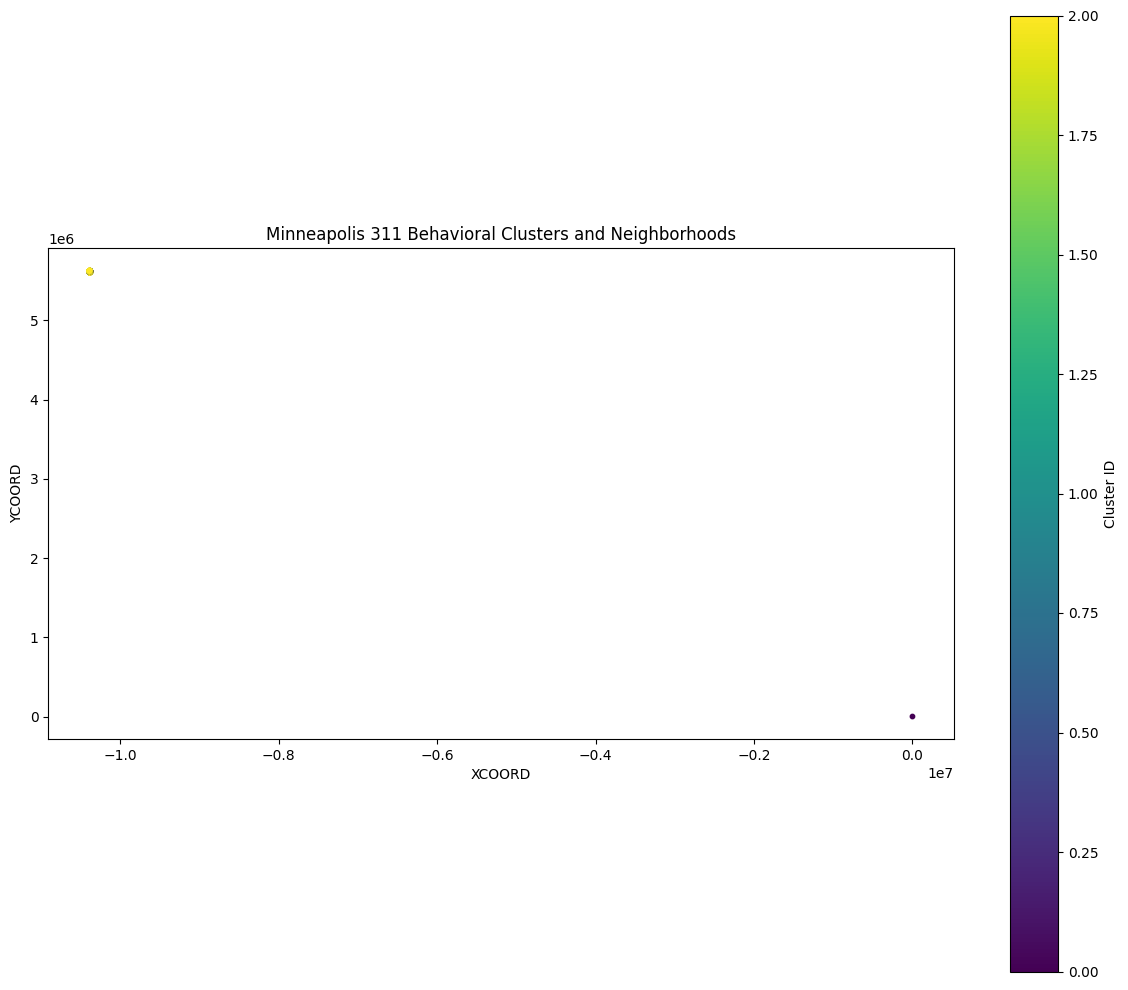

In [61]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot neighborhood boundaries
gdf_neigh.plot(ax=ax, edgecolor='black', facecolor='none')

# Overlay grid cells, colored by cluster_id
gdf_grid.plot(
    ax=ax,
    column='cluster_id',
    cmap='viridis', # Choose a colormap, 'viridis' is a good default
    legend=True,
    legend_kwds={'label': 'Cluster ID'}, # Changed 'title' to 'label'
    markersize=10
)

# Add title and labels
ax.set_title("Minneapolis 311 Behavioral Clusters and Neighborhoods")
ax.set_xlabel("XCOORD")
ax.set_ylabel("YCOORD")

plt.tight_layout()
plt.show()

In [62]:
# Filter for 'Phillips West' neighborhood
phillips_west_mix = neighborhood_cluster_mix[neighborhood_cluster_mix['BDNAME'] == 'Phillips West']

# Find the dominant cluster (cluster with the most grid counts)
if not phillips_west_mix.empty:
    dominant_cluster_id = phillips_west_mix.loc[phillips_west_mix['grid_count'].idxmax()]['cluster_id_x']
    print(f"The dominant cluster in 'Phillips West' is Cluster {int(dominant_cluster_id)}.\n")

    # Get the complaint profile for the dominant cluster
    print(f"Top REASONNAMEs for the dominant Cluster {int(dominant_cluster_id)} in 'Phillips West':")
    print(cluster_profile(dominant_cluster_id))
else:
    print("No grid cells associated with 'Phillips West' neighborhood in the cluster mix data.")

The dominant cluster in 'Phillips West' is Cluster 2.

Top REASONNAMEs for the dominant Cluster 2 in 'Phillips West':
REASONNAME
Private Property      29.652038
Animal Control        27.137931
Traffic Control       24.996865
Development Review    10.492163
Street Maintenance     6.589342
dtype: float64


In [63]:
dominant_clusters_by_neighborhood = neighborhood_cluster_mix.loc[neighborhood_cluster_mix.groupby('BDNAME')['grid_count'].idxmax()]

# Select and display relevant columns
display(dominant_clusters_by_neighborhood[['BDNAME', 'cluster_id_x']])

,BDNAME,cluster_id_x
129,Armatage,2
21,Audubon Park,2
111,Bancroft,2
39,Beltrami,0
17,Bottineau,1
...,...,...
95,West Maka Ska,1
99,Whittier,1
46,Willard - Hay,2
132,Windom,1


# Task
Count the number of neighborhoods that have each cluster as their dominant cluster, and then generate a bar chart to visualize the distribution of dominant clusters across neighborhoods. The x-axis will show the cluster IDs, and the y-axis will represent the count of neighborhoods where that cluster is dominant, including appropriate labels and a title. Finally, review the generated bar chart to understand the distribution of dominant behavioral clusters among Minneapolis neighborhoods.

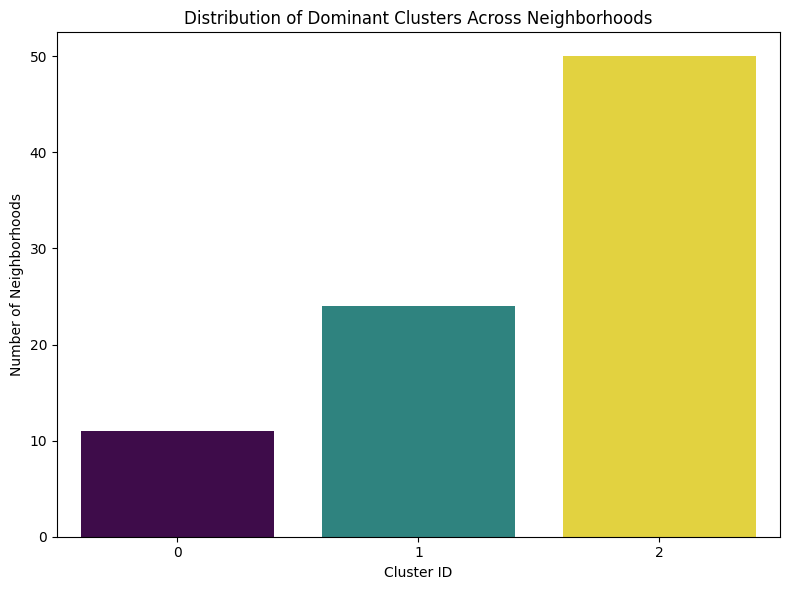

In [66]:
plt.figure(figsize=(8, 6))
sns.barplot(x=dominant_cluster_counts.index, y=dominant_cluster_counts.values, palette='viridis', hue=dominant_cluster_counts.index, legend=False)
plt.title('Distribution of Dominant Clusters Across Neighborhoods')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Neighborhoods')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Task
Merge the `dominant_clusters_by_neighborhood` DataFrame with the `gdf_neigh` GeoDataFrame to associate each neighborhood's dominant cluster with its geographical boundary. Then, generate a choropleth map of Minneapolis neighborhoods, coloring each neighborhood according to its dominant cluster ID. The map should include a title, labels, and a legend. Finally, review the generated map to interpret the spatial patterns and distribution of dominant behavioral clusters across Minneapolis neighborhoods.

## Merge Dominant Clusters with Geometries

### Subtask:
Merge the `dominant_clusters_by_neighborhood` DataFrame with the `gdf_neigh` GeoDataFrame to associate each neighborhood's dominant cluster with its geographical boundary. This will create a GeoDataFrame ready for mapping.


**Reasoning**:
To associate each neighborhood's dominant cluster with its geographical boundary, I will merge the `gdf_neigh` GeoDataFrame with the `dominant_clusters_by_neighborhood` DataFrame using 'BDNAME' as the common key.



In [67]:
merged_gdf = gdf_neigh.merge(
    dominant_clusters_by_neighborhood,
    on='BDNAME',
    how='left'
)

merged_gdf.head()

,OBJECTID,INT_REFNO,PREFIX,UDI_x,SYMBOL_NAM,BDNAME,BDNUM_x,TEXT_NBR,Shape__Area,Shape__Length,geometry,BDNUM_y,UDI_y,cluster_id_x,grid_count
0,1,-2144134800,REFNO,23152.0,WARDAREA,Phillips West,90,90,1.979108e+06,6206.097608,"POLYGON ((-10381943 5615369.383, -10382225.277...",90.0,23152.0,2.0,7.0
1,2,-2144131300,REFNO,23187.0,WARDAREA,Downtown West,87,87,3.853390e+06,8282.366210,"POLYGON ((-10381667.456 5618844.838, -10381668...",87.0,23187.0,1.0,7.0
2,3,-2144131200,REFNO,23188.0,WARDAREA,Downtown East,88,88,1.903729e+06,5788.818417,"POLYGON ((-10379984.411 5618205.632, -10379986...",88.0,23188.0,0.0,2.0
3,4,0,REFNO,23189.0,WARDAREA,Ventura Village,89,89,2.344521e+06,7313.605241,"POLYGON ((-10380495.429 5616217.16, -10380516....",89.0,23189.0,2.0,5.0
4,5,-2144137100,REFNO,23129.0,WARDAREA,Sumner - Glenwood,29,29,1.066209e+06,4769.691859,"POLYGON ((-10384805.792 5619795.531, -10384817...",29.0,23129.0,1.0,3.0


**Reasoning**:
To visualize the spatial distribution of dominant behavioral clusters, I will generate a choropleth map using the `merged_gdf` GeoDataFrame, coloring neighborhoods by their `cluster_id_x`.



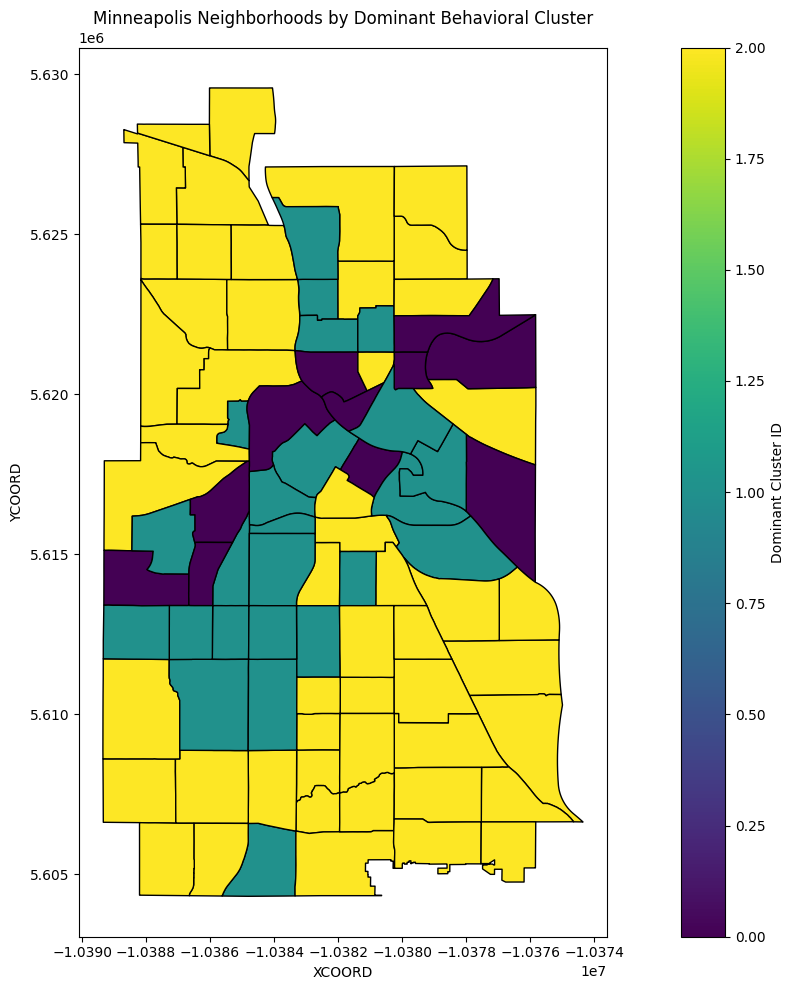

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

merged_gdf.plot(
    column='cluster_id_x',
    cmap='viridis', # Choose a colormap, e.g., 'viridis', 'Set3'
    legend=True,
    legend_kwds={'label': "Dominant Cluster ID"},
    ax=ax,
    edgecolor='black'
)

ax.set_title("Minneapolis Neighborhoods by Dominant Behavioral Cluster")
ax.set_xlabel("XCOORD")
ax.set_ylabel("YCOORD")

plt.tight_layout()
plt.show()

# Task
The previous request assumed that Cluster 2 was a single-point cluster, which is not accurate based on the `cluster_sizes` output (`cluster_id 2` has 319 grid cells). I will adjust the task to reflect this by focusing on the characteristics of Cluster 2 as a whole.

Here is the revised task:

1.  **Identify Grid IDs of Cluster 2**: Retrieve all `GRID_ID`s that are assigned to Cluster 2.
2.  **Analyze Complaint Profile of Cluster 2**: Re-display the detailed complaint profile (top `REASONNAME`s and their frequencies) for Cluster 2.
3.  **Compare with Other Cluster Profiles**: Re-display the detailed complaint profiles (top `REASONNAME`s and their frequencies) for Cluster 0 and Cluster 1 to facilitate comparison.
4.  **Examine Raw Data for Cluster 2 Grid Cells**: Retrieve and display a sample of the raw 311 data (`df_geo`) for cases that fall within the `GRID_ID`s of Cluster 2.
5.  **Synthesize Findings**: Explain what makes Cluster 2 distinct from other clusters based on its complaint profile and raw data characteristics, and discuss its implications.

## Identify Grid ID of Cluster 2

### Subtask:
Retrieve all `GRID_ID`s that are assigned to Cluster 2.


**Reasoning**:
To identify all `GRID_ID`s belonging to Cluster 2, I will filter the `pivot` DataFrame to select rows where `cluster_id` is 2 and then extract the `GRID_ID` column.



In [69]:
cluster_2_grid_ids = pivot[pivot['cluster_id'] == 2].index.tolist()
print(f"Number of GRID_IDs in Cluster 2: {len(cluster_2_grid_ids)}")
print("First 5 GRID_IDs in Cluster 2:")
print(cluster_2_grid_ids[:5])

Number of GRID_IDs in Cluster 2: 319
First 5 GRID_IDs in Cluster 2:
['(-10375676.549, 0.0]_(5610578.398, 5611300.017]', '(-10375676.549, 0.0]_(5611300.017, 5612012.831]', '(-10375676.549, 0.0]_(5612012.831, 5612824.456]', '(-10376926.951, -10375676.549]_(5604699.007, 5606756.11]', '(-10376926.951, -10375676.549]_(5606756.11, 5608302.77]']


**Reasoning**:
The previous step successfully identified the GRID_IDs for Cluster 2. Now, as per the revised task, I will re-display the detailed complaint profile (top REASONNAMEs and their frequencies) for Cluster 2 to analyze its characteristics.



In [70]:
print(f"\nCluster 2 – top REASONNAMEs:")
print(cluster_profile(2))


Cluster 2 – top REASONNAMEs:
REASONNAME
Private Property      29.652038
Animal Control        27.137931
Traffic Control       24.996865
Development Review    10.492163
Street Maintenance     6.589342
dtype: float64


**Reasoning**:
To facilitate comparison, I will now re-display the detailed complaint profiles (top REASONNAMEs and their frequencies) for Cluster 0 and Cluster 1, as requested by the revised task.



In [71]:
print(f"\nCluster 0 – top REASONNAMEs:")
print(cluster_profile(0))

print(f"\nCluster 1 – top REASONNAMEs:")
print(cluster_profile(1))


Cluster 0 – top REASONNAMEs:
REASONNAME
Private Property         52.726316
Graffiti / Clean City    50.494737
Traffic Control          44.905263
Traffic                  28.052632
Street Maintenance       18.326316
dtype: float64

Cluster 1 – top REASONNAMEs:
REASONNAME
Traffic Control          64.571429
Private Property         19.238095
Animal Control           11.500000
Graffiti / Clean City     8.398810
Development Review        7.178571
dtype: float64


**Reasoning**:
To examine the raw data for Cluster 2, I will filter the `df_geo` DataFrame to include only the rows whose `GRID_ID` is in the `cluster_2_grid_ids` list, and then display the head of this filtered DataFrame.



In [72]:
df_cluster_2_raw_data = df_geo[df_geo['GRID_ID'].isin(cluster_2_grid_ids)]
print(f"Number of raw 311 cases in Cluster 2 grid cells: {len(df_cluster_2_raw_data)}")
print("Sample of raw data for Cluster 2 grid cells:")
display(df_cluster_2_raw_data.head())

Number of raw 311 cases in Cluster 2 grid cells: 45885
Sample of raw data for Cluster 2 grid cells:


,X,Y,CASEID,OBJECTID,SUBJECTNAME,REASONNAME,TYPENAME,TITLE,OPENEDDATETIME,CASESTATUS,CLOSEDDATETIME,XCOORD,YCOORD,LastUpdateDate,POINT_X,POINT_Y,X_bin,Y_bin,GRID_ID
0,-1.037631e+07,5.607779e+06,201000513089,1,Vehicles and Commuting,Traffic Control,Abandoned Vehicle,Abandoned Vehicle,2024/01/02 07:33:00+00,0,2024/01/08 14:02:00+00,-1.037631e+07,5.607779e+06,2024/01/09 08:05:12+00,NaN,NaN,"(-10376926.951, -10375676.549]","(5606756.11, 5608302.77]","(-10376926.951, -10375676.549]_(5606756.11, 56..."
3,-1.038278e+07,5.610451e+06,201000514259,4,Property,Development Review,Permit Status Request,Permit Status Request,2024/01/05 08:42:00+00,0,2024/01/10 16:00:00+00,-1.038278e+07,5.610451e+06,2024/01/11 08:05:13+00,NaN,NaN,"(-10383000.364, -10382539.887]","(5609459.415, 5610578.398]","(-10383000.364, -10382539.887]_(5609459.415, 5..."
4,-1.038288e+07,5.604613e+06,201000514263,5,Streets,Lighting,Street Light Outage,Street Light Outage,2024/01/05 08:47:00+00,0,2024/01/05 10:43:00+00,-1.038288e+07,5.604613e+06,2024/01/06 08:05:13+00,NaN,NaN,"(-10383000.364, -10382539.887]","(-0.001, 5604699.007]","(-10383000.364, -10382539.887]_(-0.001, 560469..."
7,-1.038726e+07,5.618488e+06,201000516710,8,Property,Private Property,Rental License Followup,Rental License Followup,2024/01/16 15:56:00+00,0,2024/01/23 16:29:00+00,-1.038726e+07,5.618488e+06,2024/01/24 08:05:11+00,NaN,NaN,"(-10387806.991, -10387214.994]","(5618143.373, 5619284.928]","(-10387806.991, -10387214.994]_(5618143.373, 5..."
8,-1.038590e+07,5.622887e+06,201000516712,9,Animal Related,Animal Control,Animal Complaint - Livability,Animal Complaint - Livability,2024/01/16 15:59:00+00,0,2024/01/16 17:23:22+00,-1.038590e+07,5.622887e+06,2024/01/17 08:05:14+00,NaN,NaN,"(-10385984.392, -10385557.468]","(5622463.996, 5623456.66]","(-10385984.392, -10385557.468]_(5622463.996, 5..."


### Synthesize Findings: What Makes Cluster 2 Distinct?

Based on the complaint profiles and raw data examination, Cluster 2 (with 319 grid cells) shows a distinct behavioral signature compared to Clusters 0 and 1:

*   **Cluster 2's Top REASONNAMEs:**
    *   Private Property (29.65%)
    *   Animal Control (27.14%)
    *   Traffic Control (24.99%)
    *   Development Review (10.49%)
    *   Street Maintenance (6.59%)

*   **Cluster 0's Top REASONNAMEs (for comparison):**
    *   Private Property (52.73%)
    *   Graffiti / Clean City (50.49%)
    *   Traffic Control (44.91%)
    *   Traffic (28.05%)
    *   Street Maintenance (18.33%)

*   **Cluster 1's Top REASONNAMEs (for comparison):**
    *   Traffic Control (64.57%)
    *   Private Property (19.24%)
    *   Animal Control (11.50%)
    *   Graffiti / Clean City (8.40%)
    *   Development Review (7.18%)

**Key Distinctions of Cluster 2:**

1.  **Lower Dominance of Any Single Category:** Unlike Cluster 0, where 'Private Property' and 'Graffiti / Clean City' have very high frequencies (over 50%), and Cluster 1 where 'Traffic Control' dominates (over 64%), Cluster 2 exhibits a more balanced distribution across its top categories. The highest frequency in Cluster 2 is around 30% for 'Private Property', followed closely by 'Animal Control' and 'Traffic Control'.

2.  **Prominence of Animal Control:** 'Animal Control' is a significantly higher ranked reason in Cluster 2 (27.14%) compared to Cluster 0 (where it's not in the top 5) and Cluster 1 (11.50%). This suggests that areas in Cluster 2 have a relatively higher proportion of animal-related complaints.

3.  **Balanced 'Private Property' and 'Traffic Control':** While 'Private Property' and 'Traffic Control' are present in all top lists, in Cluster 2 their frequencies are less extreme than in the other clusters. This indicates that while these issues are common, they don't overwhelmingly define the grid cells in Cluster 2 as much as they do in Clusters 0 and 1.

4.  **Inclusion of 'Development Review':** 'Development Review' makes it into the top 5 for Cluster 2, which is also seen in Cluster 1 but at a lower percentage. This might suggest areas undergoing some development or requiring more administrative oversight.

**Implications:**

Cluster 2 represents areas with a **mixed but notably animal-related problem profile**. These are locations where the community's needs are not dominated by a single pervasive issue like heavy graffiti or overwhelming traffic control problems. Instead, they face a more diverse set of challenges, with 'Animal Control' being a distinguishing factor. This could mean these areas are more residential, potentially with more pet owners or where animal-related nuisances are more prevalent.

Policy interventions for Cluster 2 areas might need to be more generalized or specifically target animal services alongside general property maintenance and traffic management, rather than focusing solely on one dominant type of complaint. The raw data review confirms the presence of these diverse issues, from abandoned vehicles to animal complaints, in these grid cells.

## Summary:

### Q&A
**What makes Cluster 2 distinct from other clusters based on its complaint profile and raw data characteristics, and what are its implications?**
Cluster 2 is distinct because it exhibits a more balanced distribution of complaint types, with no single category overwhelmingly dominating. A key distinguishing factor is the prominence of 'Animal Control' complaints, which are significantly higher in Cluster 2 compared to the other clusters. Its raw data confirms a mix of diverse issues. This suggests Cluster 2 areas have a mixed but notably animal-related problem profile, implying that policy interventions should be more generalized or specifically target animal services alongside general property maintenance and traffic management, rather than focusing on a single pervasive issue.

### Data Analysis Key Findings
*   Cluster 2 consists of 319 unique `GRID_ID`s.
*   The top complaint reasons in Cluster 2 are 'Private Property' (29.65%), 'Animal Control' (27.14%), 'Traffic Control' (24.99%), 'Development Review' (10.49%), and 'Street Maintenance' (6.59%).
*   Unlike Cluster 0, where 'Private Property' (52.73%) and 'Graffiti / Clean City' (50.49%) are highly dominant, or Cluster 1, where 'Traffic Control' (64.57%) is overwhelming, Cluster 2 shows a more balanced distribution of complaint types.
*   'Animal Control' is a significantly more prominent reason in Cluster 2 (27.14%) compared to Cluster 1 (11.50%) and is not among the top 5 for Cluster 0, highlighting a unique characteristic of this cluster.
*   A sample of 45,885 raw 311 cases from Cluster 2 grid cells confirms the presence of diverse issues including abandoned vehicles, permit status requests, street light outages, rental license follow-ups, and animal complaints.

### Insights or Next Steps
*   Policy interventions for Cluster 2 areas should be more generalized, addressing a diverse set of issues, or specifically target animal services due to the notable prominence of 'Animal Control' complaints.
*   Further investigation into the demographics and land use patterns of Cluster 2 areas could provide additional context for the high prevalence of animal-related complaints, helping to refine targeted strategies.
